In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df_FGE = pd.read_csv('ForeignGifts_edu.csv', low_memory=False)
df_FGE.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [3]:
# Filter the dataset to institutions whose name contains the word "Virginia"
virginia_institutions = df_FGE[
    df_FGE['Institution Name']
    .str.contains('Virginia', case=False, na=False)
]

# Count how many gift records appear for each Virginia institution
virginia_institutions['Institution Name'].value_counts()

Institution Name
Virginia Commonwealth University                     115
University of Virginia                                98
West Virginia University                              33
Virginia Polytechnic Institute & State University     24
Name: count, dtype: int64

In [12]:
# Create a new DataFrame containing only University of Virginia gift records
uva = df_FGE[
    df_FGE['Institution Name'] == 'University of Virginia'
].copy()

# Check the number of rows and columns in the UVA subset
uva.shape

(98, 10)

In [13]:
uva.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26235,26236,374500,University of Virginia,Charlottesville,VA,41822,3565,Monetary Gift,ENGLAND,West Yorkshire Police
26236,26237,374500,University of Virginia,Charlottesville,VA,41870,12265,Contract,ISRAEL,CureTech Ltd
26237,26238,374500,University of Virginia,Charlottesville,VA,41873,8187,Monetary Gift,ISRAEL,Branco Weiss Institute
26238,26239,374500,University of Virginia,Charlottesville,VA,41887,6437,Contract,ISRAEL,NovoCure Ltd
26239,26240,374500,University of Virginia,Charlottesville,VA,41904,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd


In [14]:
# Calculate the total amount of foreign gifts received by UVA
uva_total = uva['Foreign Gift Amount'].sum()

# Calculate the average size of an individual UVA foreign gift
uva_mean = uva['Foreign Gift Amount'].mean()

# Calculate the median size of an individual UVA foreign gift
uva_median = uva['Foreign Gift Amount'].median()

# Count the number of UVA foreign gift records
uva_count = uva['Foreign Gift Amount'].count()

# Display the summary statistics
uva_total, uva_mean, uva_median, uva_count


(np.int64(22189238),
 np.float64(226420.79591836734),
 np.float64(80535.5),
 np.int64(98))

In [15]:
uva_summary = pd.DataFrame({
    'Matric': [
        'Total Foreign Gifts',
        'Average Gift Amount',
        'Median Gift Amount',
        'Number of Gifts'
        ],
        'Value': [
            uva_total,
            uva_mean,
            uva_median,
            uva_count
        ]
})

uva_summary

,Matric,Value
0,Total Foreign Gifts,2.218924e+07
1,Average Gift Amount,2.264208e+05
2,Median Gift Amount,8.053550e+04
3,Number of Gifts,9.800000e+01


In [16]:
# Group UVA gift records by the donor's country
# and calculate the total amount given by each country
uva_by_country = (
    uva.groupby('Country of Giftor')['Foreign Gift Amount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)


# Display the top 10 countries contributing the most money to UVA
uva_by_country.head(10)


,Country of Giftor,Foreign Gift Amount
0,BANGLADESH,4228589
1,SWEDEN,4007552
2,TANZANIA,2776447
3,SWITZERLAND,2000000
4,ENGLAND,1950666
5,GUERNSEY,1500000
6,FINLAND,1008384
7,BERMUDA,900000
8,KOREA,862787
9,SINGAPORE,805000


In [17]:
# Show UVA gift records where the giftor country is Bangladesh
uva_bangladesh = uva[
    uva['Country of Giftor'] == 'BANGLADESH'
]

# Display donor names and gift amounts
uva_bangladesh[
    ['Giftor Name', 'Foreign Gift Amount', 'Gift Type']
].sort_values('Foreign Gift Amount', ascending=False)

,Giftor Name,Foreign Gift Amount,Gift Type
26262,Intrnl Centre Diarrheal Disease,1077948,Contract
26312,Intnl Centre for Diarrhoeal Disease,919518,Contract
26326,International Centre for Diarrhoeal,919518,Contract
26264,Intl. Cntr for Diarrihoeal Disease,421278,Contract
26246,Intl Ctr for Diarrhoeal Disease,310001,Monetary Gift
26261,Intrnl Centre Diarrheal Disease,304450,Contract
26259,Intl. Cntr for Diarrihoeal Disease,275008,Monetary Gift
26263,Intrnl Centre Diarrheal Disease,498,Monetary Gift
26299,Intnl Centre for Diarrhoeal Disease,339,Monetary Gift
26268,Intl. Cntr for Diarrihoeal Disease,31,Contract


**I wanted to examine the Giftor Name and Gift Type for Bangladesh because the large amount of funding associated with the country seemed surprising. This helps clarify whether the funding came from individual donors, organizations, or contracts.**

In [18]:
# Count how many foreign gift records UVA received from each country
uva_country_count = (
    uva.groupby('Country of Giftor')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='Number of Gifts')
)

# Display the 10 countries with the most gift records to UVA
uva_country_count.head(10)

,Country of Giftor,Number of Gifts
0,ENGLAND,31
1,ISRAEL,12
2,BANGLADESH,10
3,SWEDEN,10
4,FINLAND,7
5,KOREA,6
6,FRANCE,5
7,THE NETHERLANDS,4
8,GUERNSEY,3
9,TANZANIA,3


In [19]:
# Group UVA gifts by country and calculate
# total amount, number of gifts, and average gift size
uva_country_summary = (
    uva.groupby('Country of Giftor')['Foreign Gift Amount']
    .agg(
        Total_Amount='sum',
        Number_of_Gifts='count',
        Average_Gift='mean'
    )
    .sort_values('Total_Amount', ascending=False)
    .reset_index()
)

# Check that the table was created
uva_country_summary.head()

,Country of Giftor,Total_Amount,Number_of_Gifts,Average_Gift
0,BANGLADESH,4228589,10,422858.900000
1,SWEDEN,4007552,10,400755.200000
2,TANZANIA,2776447,3,925482.333333
3,SWITZERLAND,2000000,2,1000000.000000
4,ENGLAND,1950666,31,62924.709677


In [21]:
# Create a copy for formatting
uva_country_summary_display = uva_country_summary.copy()

# Format money columns with dollar signs and commas
uva_country_summary_display['Total_Amount'] = (
    uva_country_summary_display['Total_Amount']
    .map('${:,.0f}'.format)
)

uva_country_summary_display['Average_Gift'] = (
    uva_country_summary_display['Average_Gift']
    .map('${:,.0f}'.format)
)

# Show the top 10 countries
uva_country_summary_display.head(10)

,Country of Giftor,Total_Amount,Number_of_Gifts,Average_Gift
0,BANGLADESH,"$4,228,589",10,"$422,859"
1,SWEDEN,"$4,007,552",10,"$400,755"
2,TANZANIA,"$2,776,447",3,"$925,482"
3,SWITZERLAND,"$2,000,000",2,"$1,000,000"
4,ENGLAND,"$1,950,666",31,"$62,925"
5,GUERNSEY,"$1,500,000",3,"$500,000"
6,FINLAND,"$1,008,384",7,"$144,055"
7,BERMUDA,"$900,000",1,"$900,000"
8,KOREA,"$862,787",6,"$143,798"
9,SINGAPORE,"$805,000",2,"$402,500"


### UVA Foreign Funding by Country

UVA's foreign funding is concentrated among a relatively small number of countries, but the nature of those relationships differs.

Bangladesh and Sweden contribute the largest total amounts, each providing approximately **$4 million**. Tanzania and Switzerland have fewer recorded transactions, but much larger average amounts per transaction.

England stands out as UVA's most frequent foreign funding source, with **31 recorded gifts or contracts**, although its average transaction size is much smaller at approximately **$63,000**.

This suggests that some countries have fewer but larger funding relationships with UVA, while others, such as England, have more frequent but smaller transactions.

In [22]:
# Group UVA records by gift type
# and calculate the total amount for each type
uva_gift_type_summary = (
    uva.groupby('Gift Type')['Foreign Gift Amount']
    .agg(
        Total_Amount='sum',
        Number_of_Records='count',
        Average_Amount='mean'
    )
    .sort_values('Total_Amount', ascending=False)
    .reset_index()
)

# Display the summary
uva_gift_type_summary

,Gift Type,Total_Amount,Number_of_Records,Average_Amount
0,Contract,14807636,64,231369.312500
1,Monetary Gift,7381602,34,217105.941176


### UVA Foreign Funding by Gift Type

Most of UVA's foreign funding in the dataset comes from **contracts** rather than traditional monetary gifts.

UVA received approximately **$14.8 million** through 64 contract-related records, compared with approximately **$7.38 million** through 34 monetary gifts.

The average transaction sizes are fairly similar, at about **$231,000** for contracts and **$217,000** for monetary gifts.

This suggests that UVA's international funding relationships are driven more heavily by research, institutional, or contractual arrangements than by purely philanthropic donations.

**Now I want to identify UVA’s top individual giftors to see show which organizations or donors account for the most foreign funding to UVA.**

In [23]:
# Group UVA records by giftor name
# and calculate the total amount associated with each giftor
uva_top_giftors = (
    uva.groupby('Giftor Name')['Foreign Gift Amount']
    .agg(
        Total_Amount='sum',
        Number_of_Records='count',
        Average_Amount='mean'
    )
    .sort_values('Total_Amount', ascending=False)
    .reset_index()
)

# Display the top 10 giftors to UVA
uva_top_giftors.head(10)

,Giftor Name,Total_Amount,Number_of_Records,Average_Amount
0,AstraZeneca,3208048,2,1.604024e+06
1,Intrnl Centre Diarrheal Disease,1382896,3,4.609653e+05
2,Haydom Lutheran Hospital d/b/a Hayd,1100553,1,1.100553e+06
3,Haydom Luther Hospital,1035339,1,1.035339e+06
4,Harvest Group Holding,1000000,2,5.000000e+05
5,Lawrence D/ Karin S Howell,1000000,1,1.000000e+06
6,Lawrence D & Karin S Howell,1000000,1,1.000000e+06
7,Danisco Sweeteners Oy,990331,4,2.475828e+05
8,Intnl Centre for Diarrhoeal Disease,919857,2,4.599285e+05
9,International Centre for Diarrhoeal,919518,1,9.195180e+05


### The output reveals a data-cleaning issue before we compare UVA donors. 
- For example: these likely refer to the same organization:
    - Intrnl Centre Diarrheal Disease
    - Intnl Centre for Diarrhoeal Disease
    - International Centre for Diarrhoeal ...
- Also: these also appear to be duplicates:
    - Haydom Lutheran Hospital d/b/a Hayd
    - Haydom Luther Hospital
- Likewise:
    - Lawrence D/ Karin S Howell
    - Lawrence D & Karin S Howell

**So if we rank donors before cleaning these names, we may underestimate how much a donor actually contributed because its total is split across several spellings.**

In [24]:
# Display all unique UVA giftor names in alphabetical order
# so we can identify duplicate or inconsistent spellings
sorted(uva['Giftor Name'].dropna().unique())

['Adelphi Group Limited',
 'AstraZeneca',
 'Atox Bio Ltd.',
 'AutoLiv Development AB',
 'BSP-Biological Signal Proc Ltd',
 "Biom 'Up",
 'Branco Weiss Institute',
 'Chalmers University of Technology',
 'Charities Aid Foundation',
 'Charles Aid Foundation',
 'CureTech Ltd',
 'Daegu Gyeongbuk Inst of Sc& Tech',
 'Daegu Gyeongbuk Inst of Sci & Tech',
 'Danisco Sweeteners Oy',
 'Elekta Instrument AB',
 'Emergent Countermeasures Intnl',
 'FKD Therapies Oy',
 'G. W. Research Ltd',
 'GW Research Ltd',
 'GW Research Ltd.',
 'Galmed Research & Development Ltd',
 'Genfit',
 'Genmab B.V.',
 'Harvest Group Holding',
 'Harvest Group Holding (PTC Limited)',
 'Haydom Luther Hospital',
 'Haydom Lutheran Hospital',
 'Haydom Lutheran Hospital d/b/a Hayd',
 'Hemera Foundation',
 'Honda R & D Co., LTD',
 'Human Frontier Science Program',
 'Hyundai Motor Company',
 'InSightec-Image Guide Treatment Ltd',
 'InSightec-Image Guided Treatment Lt',
 'International Centre for Diarrhoeal',
 'Intl Ctr for Diarrhoeal

In [25]:
# Import a fuzzy matching function
from rapidfuzz.fuzz import ratio

# Get all unique non-missing UVA giftor names
giftor_names = sorted(
    uva['Giftor Name']
    .dropna()
    .unique()
)

# Create an empty list to store likely duplicate pairs
similar_names = []

# Compare every giftor name with every other giftor name
for i in range(len(giftor_names)):
    for j in range(i + 1, len(giftor_names)):
        
        name1 = giftor_names[i]
        name2 = giftor_names[j]

        # Calculate similarity score from 0 to 100
        score = ratio(name1, name2)

        # Keep only highly similar names
        if score >= 80:
            similar_names.append(
                {
                    'Name 1': name1,
                    'Name 2': name2,
                    'Similarity': score
                }
            )

# Convert results to a DataFrame
similar_names_df = pd.DataFrame(similar_names)

# Sort so the most similar pairs appear first
similar_names_df = similar_names_df.sort_values(
    'Similarity',
    ascending=False
)

# Display the results
similar_names_df

,Name 1,Name 2,Similarity
15,TauRx Therapeutics Ltd,TauRx Therapeutics Ltd.,97.777778
7,InSightec-Image Guide Treatment Ltd,InSightec-Image Guided Treatment Lt,97.142857
1,Daegu Gyeongbuk Inst of Sc& Tech,Daegu Gyeongbuk Inst of Sci & Tech,96.969697
4,GW Research Ltd,GW Research Ltd.,96.774194
5,Haydom Luther Hospital,Haydom Lutheran Hospital,95.652174
8,Intl Ctr for Diarrhoeal Disease,Intl. Cntr for Diarrihoeal Disease,95.384615
14,Lawrence D & Karin S Howell,Lawrence D/ Karin S Howell,94.339623
9,Intl Ctr for Diarrhoeal Disease,Intnl Centre for Diarrhoeal Disease,93.939394
11,Intl. Cntr for Diarrihoeal Disease,Intnl Centre for Diarrhoeal Disease,92.753623
0,Charities Aid Foundation,Charles Aid Foundation,91.304348


In [26]:
# Create a mapping that combines obvious duplicate donor names
giftor_name_mapping = {

    # GW Research
    'G. W. Research Ltd': 'GW Research Ltd',
    'GW Research Ltd.': 'GW Research Ltd',

    # TauRx
    'TauRx Therapeutics Ltd.': 'TauRx Therapeutics Ltd',

    # Daegu Gyeongbuk Institute
    'Daegu Gyeongbuk Inst of Sc& Tech':
        'Daegu Gyeongbuk Inst of Sci & Tech',

    # InSightec
    'InSightec-Image Guide Treatment Ltd':
        'InSightec-Image Guided Treatment Lt',

    # Haydom Lutheran Hospital
    'Haydom Luther Hospital':
        'Haydom Lutheran Hospital',
    'Haydom Lutheran Hospital d/b/a Hayd':
        'Haydom Lutheran Hospital',

    # Lawrence and Karin Howell
    'Lawrence D/ Karin S Howell':
        'Lawrence D & Karin S Howell',

    # International Centre for Diarrhoeal Disease
    'Intl Ctr for Diarrhoeal Disease':
        'International Centre for Diarrhoeal Disease',
    'Intl. Cntr for Diarrihoeal Disease':
        'International Centre for Diarrhoeal Disease',
    'Intnl Centre for Diarrhoeal Disease':
        'International Centre for Diarrhoeal Disease',
    'Intrnl Centre Diarrheal Disease':
        'International Centre for Diarrhoeal Disease',
    'International Centre for Diarrhoeal':
        'International Centre for Diarrhoeal Disease'
}

In [27]:
# Create a new cleaned donor-name column
# Names not found in the mapping remain unchanged
uva['Giftor Name Clean'] = (
    uva['Giftor Name']
    .replace(giftor_name_mapping)
)

In [28]:
# Recalculate donor statistics using standardized donor names
uva_top_giftors_clean = (
    uva.groupby('Giftor Name Clean')['Foreign Gift Amount']
    .agg(
        Total_Amount='sum',
        Number_of_Records='count',
        Average_Amount='mean'
    )
    .sort_values('Total_Amount', ascending=False)
    .reset_index()
)

# Display the top 10 cleaned donor groups
uva_top_giftors_clean.head(10)

,Giftor Name Clean,Total_Amount,Number_of_Records,Average_Amount
0,International Centre for Diarrhoeal Disease,4228589,10,4.228589e+05
1,AstraZeneca,3208048,2,1.604024e+06
2,Haydom Lutheran Hospital,2776447,3,9.254823e+05
3,Lawrence D & Karin S Howell,2000000,2,1.000000e+06
4,Harvest Group Holding,1000000,2,5.000000e+05
5,Danisco Sweeteners Oy,990331,4,2.475828e+05
6,Hemera Foundation,900000,1,9.000000e+05
7,Rainbow Foundation,805000,2,4.025000e+05
8,Charities Aid Foundation,727928,3,2.426427e+05
9,AutoLiv Development AB,685217,5,1.370434e+05


### Top Foreign Giftors to UVA

After standardizing duplicate and inconsistent giftor names, the **International Centre for Diarrhoeal Disease** emerges as UVA's largest foreign funding partner, contributing approximately **$4.23 million across 10 records**.

Other major giftors include **AstraZeneca**, **Haydom Lutheran Hospital**, and **Lawrence D & Karin S Howell**.

Cleaning the giftor names was important because several organizations appeared under multiple spellings or abbreviations, which would otherwise have caused their total contributions to be underestimated.

In [29]:
# Search for Virginia-based institutions in the dataset
virginia_peer_search = df_FGE[
    df_FGE['Institution Name'].str.contains(
        'Virginia',
        case=False,
        na=False
    )
]

# Show the matching institution names and number of gift records
virginia_peer_search['Institution Name'].value_counts()

Institution Name
Virginia Commonwealth University                     115
University of Virginia                                98
West Virginia University                              33
Virginia Polytechnic Institute & State University     24
Name: count, dtype: int64

In [30]:
# Define regional universities for comparison with UVA
regional_peers = [
    'University of Virginia',
    'Virginia Commonwealth University',
    'Virginia Polytechnic Institute & State University',
    'West Virginia University'
]

In [31]:
# Filter the full dataset to only the selected regional universities
regional_peer_data = df_FGE[
    df_FGE['Institution Name'].isin(regional_peers)
]

# Compare total funding, number of records, average gift, and median gift
regional_peer_summary = (
    regional_peer_data
    .groupby('Institution Name')['Foreign Gift Amount']
    .agg(
        Total_Amount='sum',
        Number_of_Records='count',
        Average_Gift='mean',
        Median_Gift='median'
    )
    .sort_values('Total_Amount', ascending=False)
    .reset_index()
)

# Display the comparison table
regional_peer_summary

,Institution Name,Total_Amount,Number_of_Records,Average_Gift,Median_Gift
0,Virginia Commonwealth University,89163583,115,775335.504348,33750.0
1,University of Virginia,22189238,98,226420.795918,80535.5
2,West Virginia University,18509865,33,560905.000000,335000.0
3,Virginia Polytechnic Institute & State University,11792062,24,491335.916667,350000.0


## Regional Peer Comparison

Among the selected regional universities, **Virginia Commonwealth University (VCU)** receives the largest total amount of foreign funding, with approximately **$89.2 million** across 115 records.

The **University of Virginia** ranks second, receiving approximately **$22.2 million** across 98 records.

Although VCU has a very high average gift amount, its much lower median suggests that a small number of very large transactions significantly increase the average. UVA has a lower average gift amount but a higher median than VCU, indicating a somewhat less skewed distribution.

West Virginia University and Virginia Tech receive fewer foreign funding records overall, but their median transaction sizes are considerably larger than UVA's.

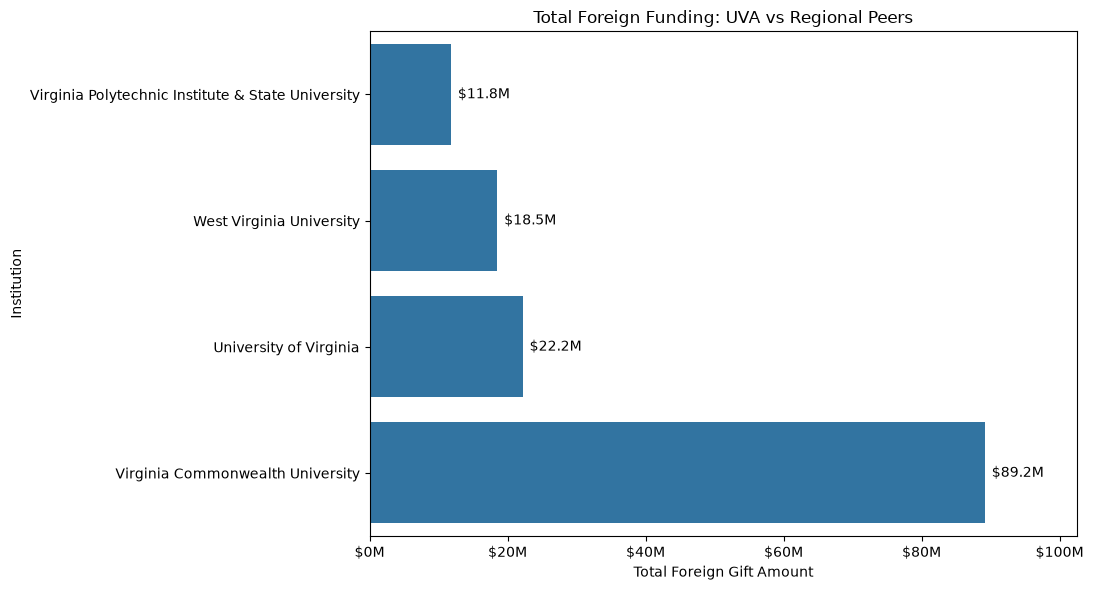

In [32]:
# Import ticker formatting tools from matplotlib
from matplotlib.ticker import FuncFormatter

# Sort institutions by total foreign funding
regional_peer_plot = regional_peer_summary.sort_values(
    'Total_Amount',
    ascending=True
)

# Create the figure
plt.figure(figsize=(11, 6))

# Create the horizontal bar chart
ax = sns.barplot(
    data=regional_peer_plot,
    x='Total_Amount',
    y='Institution Name'
)

# Format the x-axis in millions of dollars
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x/1_000_000:.0f}M')
)

# Add the actual total amount at the end of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f'${value/1_000_000:.1f}M'
            for value in regional_peer_plot['Total_Amount']
        ],
        padding=5
    )

# Add title and axis labels
plt.title('Total Foreign Funding: UVA vs Regional Peers')
plt.xlabel('Total Foreign Gift Amount')
plt.ylabel('Institution')

# Add some extra space so the labels do not get cut off
plt.xlim(
    0,
    regional_peer_plot['Total_Amount'].max() * 1.15
)

# Adjust spacing
plt.tight_layout()

# Display the chart
plt.show()

### Regional Foreign Funding Comparison

Among the selected regional institutions, **Virginia Commonwealth University** receives by far the largest amount of foreign funding, at approximately **$89.2 million**.

The **University of Virginia** ranks second with approximately **$22.2 million**, followed by **West Virginia University** at about **$18.5 million** and **Virginia Tech** at about **$11.8 million**.

This indicates that UVA performs relatively well compared with nearby institutions, but there is a substantial gap between UVA and VCU in total foreign funding.

## National Peer Comparison

In [33]:
# Create a summary table for every institution in the dataset
institution_summary = (
    df_FGE.groupby('Institution Name')['Foreign Gift Amount']
    .agg(
        Total_Amount='sum',
        Number_of_Records='count',
        Average_Gift='mean',
        Median_Gift='median'
    )
    .reset_index()
)

# Display the first few rows
institution_summary.head()

,Institution Name,Total_Amount,Number_of_Records,Average_Gift,Median_Gift
0,Adelphi University,1000000,3,3.333333e+05,250000.0
1,Albert Einstein College of Medicine,4252385,6,7.087308e+05,668340.5
2,Alfred University,2711699,2,1.355850e+06,1355849.5
3,American University (The),3489000,4,8.722500e+05,994500.0
4,Amherst College,778723,2,3.893615e+05,389361.5


In [34]:
# Extract UVA's summary statistics
uva_metrics = institution_summary[
    institution_summary['Institution Name'] == 'University of Virginia'
]

uva_metrics

,Institution Name,Total_Amount,Number_of_Records,Average_Gift,Median_Gift
282,University of Virginia,22189238,98,226420.795918,80535.5


In [35]:
# Import StandardScaler to standardize variables
from sklearn.preprocessing import StandardScaler

# Select the numeric features we want to use to define peer similarity
peer_features = institution_summary[
    [
        'Total_Amount',
        'Number_of_Records',
        'Average_Gift',
        'Median_Gift'
    ]
]

# Create the scaler
scaler = StandardScaler()

# Standardize all four metrics
scaled_features = scaler.fit_transform(peer_features)

In [36]:
# Find UVA's row index in institution_summary
uva_index = institution_summary[
    institution_summary['Institution Name'] == 'University of Virginia'
].index[0]

# Get UVA's standardized values
uva_scaled = scaled_features[uva_index]

# Calculate Euclidean distance between UVA and every institution
institution_summary['Peer_Distance'] = np.sqrt(
    ((scaled_features - uva_scaled) ** 2).sum(axis=1)
)

# Remove UVA itself and rank institutions from most similar to least similar
national_peers_data_driven = (
    institution_summary[
        institution_summary['Institution Name'] != 'University of Virginia'
    ]
    .sort_values('Peer_Distance')
)

# Display the 10 institutions most similar to UVA
national_peers_data_driven.head(10)

,Institution Name,Total_Amount,Number_of_Records,Average_Gift,Median_Gift,Peer_Distance
295,Washington State University,23975181,112,214064.116071,26955.5,0.060638
152,Oregon State University,26357408,85,310087.152941,20349.0,0.077483
296,Washington University in St. Louis,30996146,91,340616.989011,122665.0,0.088785
144,Northwood University,11159755,105,106283.380952,62838.0,0.097287
230,University of Kansas,33560295,115,291828.652174,62241.0,0.100120
231,University of Kentucky,24971560,82,304531.219512,199729.5,0.104879
220,University of Georgia,17797759,124,143530.314516,11230.0,0.111274
205,"University of California, Santa Barbara",28640020,101,283564.554455,234000.0,0.113983
235,"University of Maryland, College Park",29933278,86,348061.372093,194287.5,0.116388
183,"Teachers College, Columbia University",20817997,61,341278.639344,28472.0,0.142280


### Data-Driven National Peer Selection

To identify national peers for UVA, institutions were compared using four foreign-funding measures: total foreign funding, number of funding records, average transaction amount, and median transaction amount.

Because these variables are measured on very different scales, they were standardized before calculating Euclidean distance from UVA. Institutions with smaller distances have foreign-funding profiles more similar to UVA.

The resulting peer list was then reviewed to retain institutions that are also reasonable higher-education comparisons to UVA.

### AI Assistance

I used **ChatGPT (OpenAI)** for guidance on using:

```python
from sklearn.preprocessing import StandardScaler

I initially considered manually choosing several national universities to compare with UVA. Instead, I wanted to use the information already available in the dataset to identify institutions with foreign-funding patterns that are similar to UVA.

ChatGPT suggested using `StandardScaler` so that variables such as **total foreign funding, number of records, average gift amount, and median gift amount** could be placed on the same scale before comparing universities. This helped prevent variables with much larger numeric values, such as total funding, from dominating the comparison.

I then used the standardized metrics to calculate similarity between UVA and other institutions and used those results as a data-driven starting point for selecting national peers.

**Citation:** OpenAI. (2026). *ChatGPT* [Large language model]. [https://chatgpt.com/](https://chatgpt.com/)

#### Creating a clean comparison table of UVA plus the selected national peers

In [38]:
# Define the national peers selected from the data-driven similarity analysis
national_peers = [
    'University of Virginia',
    'Washington State University',
    'Oregon State University',
    'University of Kansas',
    'University of Kentucky',
    'University of Georgia',
    'University of California-Santa Barbara',
    'University of Maryland-College Park'
]

In [39]:
# Display the exact institution names from the closest peer results
national_peers_data_driven[
    ['Institution Name', 'Peer_Distance']
].head(10)

,Institution Name,Peer_Distance
295,Washington State University,0.060638
152,Oregon State University,0.077483
296,Washington University in St. Louis,0.088785
144,Northwood University,0.097287
230,University of Kansas,0.100120
231,University of Kentucky,0.104879
220,University of Georgia,0.111274
205,"University of California, Santa Barbara",0.113983
235,"University of Maryland, College Park",0.116388
183,"Teachers College, Columbia University",0.142280


In [40]:
# Filter the institution summary to UVA and the selected national peers
national_peer_summary = institution_summary[
    institution_summary['Institution Name'].isin(national_peers)
].copy()

# Sort the universities by total foreign funding
national_peer_summary = (
    national_peer_summary
    .sort_values('Total_Amount', ascending=False)
    .reset_index(drop=True)
)

# Keep only the columns useful for comparison
national_peer_summary = national_peer_summary[
    [
        'Institution Name',
        'Total_Amount',
        'Number_of_Records',
        'Average_Gift',
        'Median_Gift',
        'Peer_Distance'
    ]
]

# Display the comparison
national_peer_summary

,Institution Name,Total_Amount,Number_of_Records,Average_Gift,Median_Gift,Peer_Distance
0,University of Kansas,33560295,115,291828.652174,62241.0,0.100120
1,Oregon State University,26357408,85,310087.152941,20349.0,0.077483
2,University of Kentucky,24971560,82,304531.219512,199729.5,0.104879
3,Washington State University,23975181,112,214064.116071,26955.5,0.060638
4,University of Virginia,22189238,98,226420.795918,80535.5,0.000000
5,University of Georgia,17797759,124,143530.314516,11230.0,0.111274


In [44]:
# Take the first 10 data-driven peers
top_10_peers = national_peers_data_driven.head(10)

# Get their exact institution names from the dataset
national_peers = top_10_peers['Institution Name'].tolist()

# Add UVA itself to the list
national_peers.append('University of Virginia')

# Check the names
national_peers

['Washington State University',
 'Oregon State University',
 'Washington University in St. Louis',
 'Northwood University',
 'University of Kansas',
 'University of Kentucky',
 'University of Georgia',
 'University of California, Santa Barbara',
 'University of Maryland, College Park',
 'Teachers College, Columbia University',
 'University of Virginia']

In [45]:
# Filter the institution summary using the exact names
national_peer_summary = institution_summary[
    institution_summary['Institution Name'].isin(national_peers)
].copy()

# Sort by total foreign funding
national_peer_summary = (
    national_peer_summary
    .sort_values('Total_Amount', ascending=False)
    .reset_index(drop=True)
)

# Keep the useful comparison columns
national_peer_summary = national_peer_summary[
    [
        'Institution Name',
        'Total_Amount',
        'Number_of_Records',
        'Average_Gift',
        'Median_Gift',
        'Peer_Distance'
    ]
]

# Display all selected peers plus UVA
national_peer_summary

,Institution Name,Total_Amount,Number_of_Records,Average_Gift,Median_Gift,Peer_Distance
0,University of Kansas,33560295,115,291828.652174,62241.0,0.100120
1,Washington University in St. Louis,30996146,91,340616.989011,122665.0,0.088785
2,"University of Maryland, College Park",29933278,86,348061.372093,194287.5,0.116388
3,"University of California, Santa Barbara",28640020,101,283564.554455,234000.0,0.113983
4,Oregon State University,26357408,85,310087.152941,20349.0,0.077483
5,University of Kentucky,24971560,82,304531.219512,199729.5,0.104879
6,Washington State University,23975181,112,214064.116071,26955.5,0.060638
7,University of Virginia,22189238,98,226420.795918,80535.5,0.000000
8,"Teachers College, Columbia University",20817997,61,341278.639344,28472.0,0.142280
9,University of Georgia,17797759,124,143530.314516,11230.0,0.111274


**Removing the less appropriate institutional matches(Northwood University,Teachers College, Columbia University) and keep the stronger national peers.**

In [46]:
# Final national peer universities selected from the data-driven results
national_peers = [
    'University of Virginia',
    'Washington State University',
    'Oregon State University',
    'Washington University in St. Louis',
    'University of Kansas',
    'University of Kentucky',
    'University of Georgia',
    'University of California, Santa Barbara',
    'University of Maryland, College Park'
]

In [47]:
# Filter the institution summary to UVA and the final national peers
national_peer_summary = institution_summary[
    institution_summary['Institution Name'].isin(national_peers)
].copy()

# Sort by total foreign funding
national_peer_summary = (
    national_peer_summary
    .sort_values('Total_Amount', ascending=False)
    .reset_index(drop=True)
)

# Keep the useful comparison columns
national_peer_summary = national_peer_summary[
    [
        'Institution Name',
        'Total_Amount',
        'Number_of_Records',
        'Average_Gift',
        'Median_Gift',
        'Peer_Distance'
    ]
]

# Display the final national peer table
national_peer_summary

,Institution Name,Total_Amount,Number_of_Records,Average_Gift,Median_Gift,Peer_Distance
0,University of Kansas,33560295,115,291828.652174,62241.0,0.100120
1,Washington University in St. Louis,30996146,91,340616.989011,122665.0,0.088785
2,"University of Maryland, College Park",29933278,86,348061.372093,194287.5,0.116388
3,"University of California, Santa Barbara",28640020,101,283564.554455,234000.0,0.113983
4,Oregon State University,26357408,85,310087.152941,20349.0,0.077483
5,University of Kentucky,24971560,82,304531.219512,199729.5,0.104879
6,Washington State University,23975181,112,214064.116071,26955.5,0.060638
7,University of Virginia,22189238,98,226420.795918,80535.5,0.000000
8,University of Georgia,17797759,124,143530.314516,11230.0,0.111274


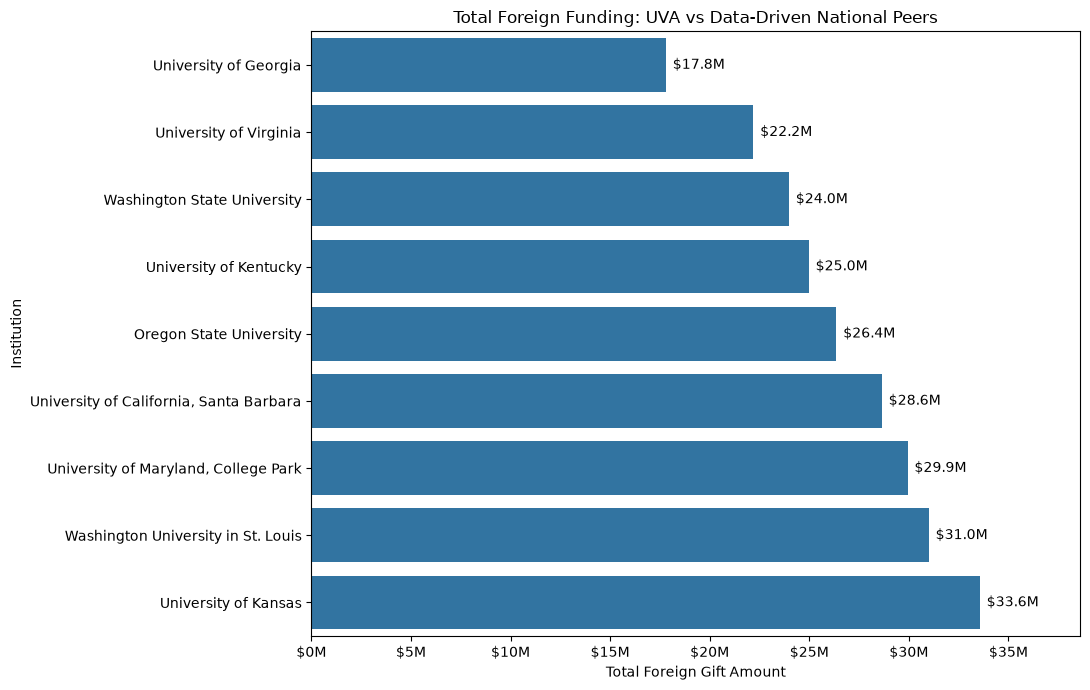

In [48]:
# Sort values so the horizontal bars appear from smallest to largest
national_peer_plot = national_peer_summary.sort_values(
    'Total_Amount',
    ascending=True
)

# Create the figure
plt.figure(figsize=(11, 7))

# Create a horizontal bar chart
ax = sns.barplot(
    data=national_peer_plot,
    x='Total_Amount',
    y='Institution Name'
)

# Format the x-axis in millions of dollars
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x / 1_000_000:.0f}M')
)

# Add the dollar amount at the end of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f'${value / 1_000_000:.1f}M'
            for value in national_peer_plot['Total_Amount']
        ],
        padding=5
    )

# Add title and axis labels
plt.title('Total Foreign Funding: UVA vs Data-Driven National Peers')
plt.xlabel('Total Foreign Gift Amount')
plt.ylabel('Institution')

# Add extra room for the labels at the end of the bars
plt.xlim(
    0,
    national_peer_plot['Total_Amount'].max() * 1.15
)

# Improve spacing
plt.tight_layout()

# Display the chart
plt.show()

### National Peer Comparison

Compared with the selected data-driven national peers, UVA received approximately **$22.2 million** in total foreign funding.

UVA received less total foreign funding than most of the peer institutions in this comparison. The closest institutions in total funding were **Washington State University ($24.0M)**, **University of Kentucky ($25.0M)**, and **Oregon State University ($26.4M)**.

The **University of Kansas** had the largest total among this peer group at approximately **$33.6 million**, while the **University of Georgia** had the smallest total at approximately **$17.8 million**.

Overall, UVA appears to fall toward the lower-middle range of this peer group in terms of total foreign funding. However, total funding alone does not show whether institutions receive many small transactions or fewer large transactions, so additional measures such as the median gift amount are also useful for comparison.

**Then, I’d compare the median gift amount across these same universities. That will tell us something different from total funding: what a more “typical” funding transaction looks like at each institution.**

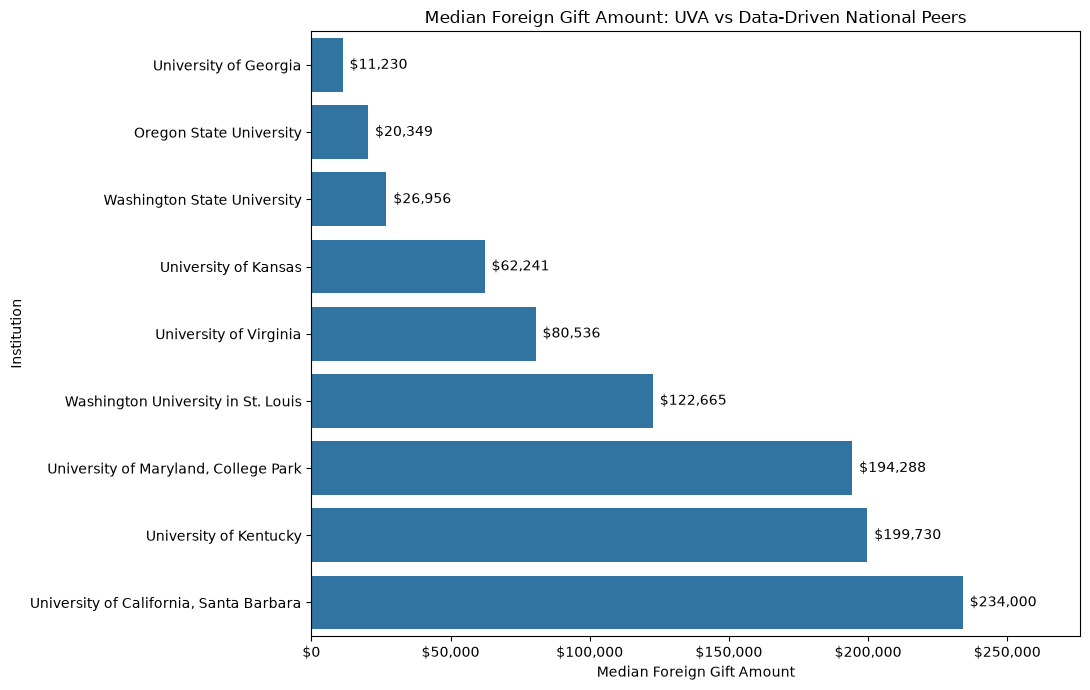

In [49]:
# Sort the universities by median gift amount
national_peer_median_plot = national_peer_summary.sort_values(
    'Median_Gift',
    ascending=True
)

# Create the figure
plt.figure(figsize=(11, 7))

# Create a horizontal bar chart
ax = sns.barplot(
    data=national_peer_median_plot,
    x='Median_Gift',
    y='Institution Name'
)

# Format the x-axis as dollar amounts
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x:,.0f}')
)

# Add the median gift amount at the end of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f'${value:,.0f}'
            for value in national_peer_median_plot['Median_Gift']
        ],
        padding=5
    )

# Add chart title and labels
plt.title('Median Foreign Gift Amount: UVA vs Data-Driven National Peers')
plt.xlabel('Median Foreign Gift Amount')
plt.ylabel('Institution')

# Add some extra space for the labels
plt.xlim(
    0,
    national_peer_median_plot['Median_Gift'].max() * 1.18
)

# Improve spacing
plt.tight_layout()

# Display the chart
plt.show()

### Median Foreign Gift Comparison

UVA's median foreign gift amount is approximately **$80,536**. This means that half of UVA's recorded foreign-funding transactions are below this amount and half are above it.

Compared with the selected national peers, UVA's median gift amount is higher than those of the **University of Georgia, Oregon State University, Washington State University, and the University of Kansas**.

However, UVA's median is lower than those of **Washington University in St. Louis, the University of Maryland, the University of Kentucky, and the University of California, Santa Barbara**.

This comparison shows that although UVA is toward the lower-middle of the peer group in terms of total foreign funding, its typical foreign-funding transaction is relatively substantial compared with several peers.

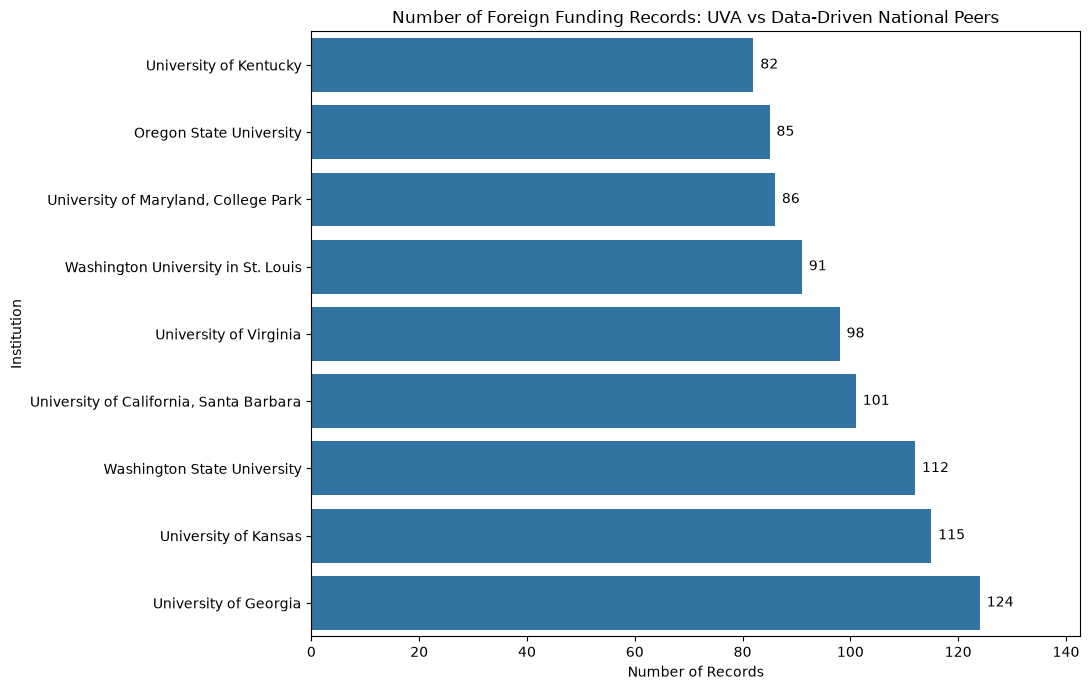

In [50]:
# Sort universities by number of foreign-funding records
national_peer_count_plot = national_peer_summary.sort_values(
    'Number_of_Records',
    ascending=True
)

# Create the figure
plt.figure(figsize=(11, 7))

# Create a horizontal bar chart
ax = sns.barplot(
    data=national_peer_count_plot,
    x='Number_of_Records',
    y='Institution Name'
)

# Add the number of records at the end of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f'{value:,.0f}'
            for value in national_peer_count_plot['Number_of_Records']
        ],
        padding=5
    )

# Add chart title and labels
plt.title('Number of Foreign Funding Records: UVA vs Data-Driven National Peers')
plt.xlabel('Number of Records')
plt.ylabel('Institution')

# Add extra space for labels
plt.xlim(
    0,
    national_peer_count_plot['Number_of_Records'].max() * 1.15
)

# Improve spacing
plt.tight_layout()

# Display the chart
plt.show()

### Number of Foreign Funding Records

UVA has **98 foreign-funding records**, placing it near the middle of the selected national peer group.

Some universities have more recorded foreign-funding transactions, including the **University of Georgia (124)**, **University of Kansas (115)**, **Washington State University (112)**, and **UC Santa Barbara (101)**.

Others have fewer records, including **Washington University in St. Louis (91)**, **University of Maryland, College Park (86)**, **Oregon State University (85)**, and **University of Kentucky (82)**.

This suggests that UVA's overall foreign-funding activity is not unusually high or low in terms of transaction frequency. Its position is fairly typical among these peers.

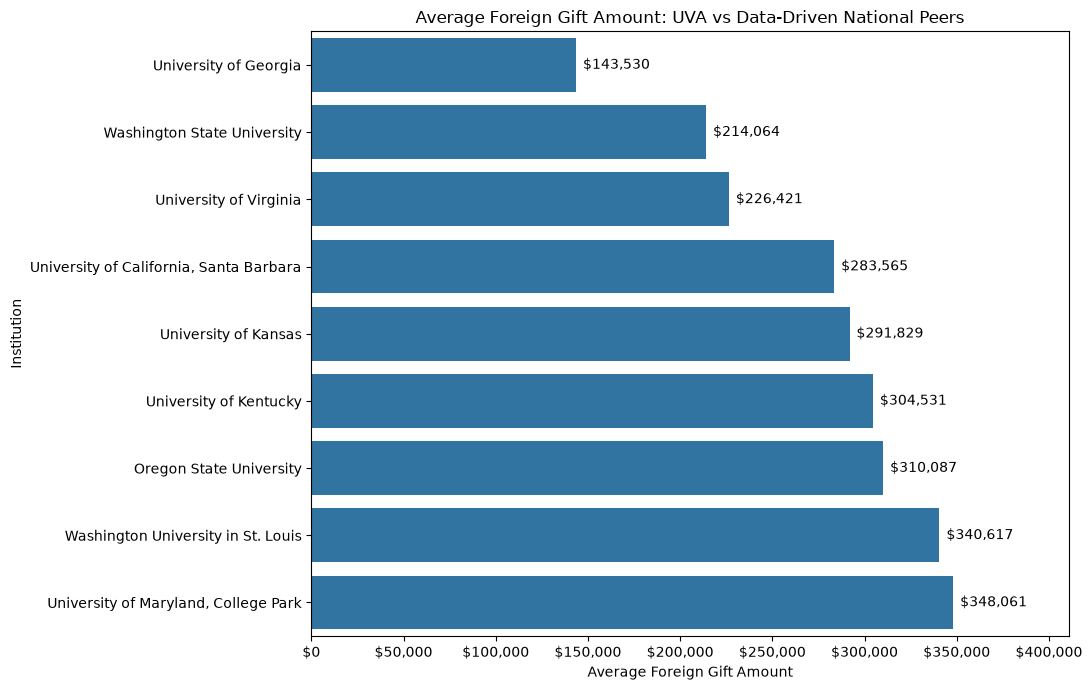

In [51]:
# Sort universities by average foreign gift amount
national_peer_average_plot = national_peer_summary.sort_values(
    'Average_Gift',
    ascending=True
)

# Create the figure
plt.figure(figsize=(11, 7))

# Create a horizontal bar chart
ax = sns.barplot(
    data=national_peer_average_plot,
    x='Average_Gift',
    y='Institution Name'
)

# Format the x-axis as dollar amounts
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x:,.0f}')
)

# Add the average gift amount at the end of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f'${value:,.0f}'
            for value in national_peer_average_plot['Average_Gift']
        ],
        padding=5
    )

# Add chart title and labels
plt.title('Average Foreign Gift Amount: UVA vs Data-Driven National Peers')
plt.xlabel('Average Foreign Gift Amount')
plt.ylabel('Institution')

# Add extra space for the labels
plt.xlim(
    0,
    national_peer_average_plot['Average_Gift'].max() * 1.18
)

# Improve spacing
plt.tight_layout()

# Display the chart
plt.show()

### Average Foreign Gift Comparison

UVA's average foreign gift amount is approximately **$226,421**.

Compared with the selected national peers, UVA's average gift is higher than those of the **University of Georgia** and **Washington State University**, but lower than the averages for the other institutions in the peer group.

An important observation is that UVA's average gift amount (**$226,421**) is much higher than its median gift amount (**$80,536**). This suggests that UVA's foreign-funding distribution is right-skewed, meaning that a relatively small number of large transactions are increasing the average.

Therefore, the median may provide a better picture of a typical foreign-funding transaction at UVA, while the average helps show the influence of larger gifts or contracts.

<div style="
    background-color:#e8eef7;
    color:#111111;
    padding:18px;
    border-radius:10px;
    border-left:6px solid #4a6fa5;
">

### Overall National Peer Comparison

Across the selected data-driven national peer institutions, UVA appears to fall around the **middle of the group overall**, but its position changes depending on the metric being considered.

In terms of **total foreign funding**, UVA received approximately **$22.2 million**, which is lower than most of the selected peers. However, UVA's total is still relatively close to institutions such as Washington State University, the University of Kentucky, and Oregon State University.

For the **number of foreign-funding records**, UVA has **98 records**, placing it near the middle of the peer group. This suggests that UVA is not unusual in terms of the frequency of foreign-funding transactions.

UVA's **median foreign gift amount** is approximately **$80,536**, which is higher than several peers, including the University of Georgia, Oregon State University, Washington State University, and the University of Kansas.

At the same time, UVA's **average gift amount** is approximately **$226,421**, which is much higher than its median. This suggests that UVA's foreign-funding distribution is right-skewed, with a smaller number of large transactions pulling the average upward.

Overall, UVA does not lead this peer group in total foreign funding, but its funding profile is not weak. It has a moderate number of transactions and a relatively strong median gift amount.

</div>

### Potential Funding opportunities for UVA?
**Which countries provide substantial foreign funding to UVA’s national peers, but relatively little or none to UVA?**

In [52]:
# Keep only UVA and the final national peer universities
national_peer_raw = df_FGE[
    df_FGE['Institution Name'].isin(national_peers)
].copy()

# Check how many records are included
national_peer_raw.shape

(894, 10)

In [53]:
# Calculate UVA's total foreign funding from each country
uva_country_funding = (
    national_peer_raw[
        national_peer_raw['Institution Name'] == 'University of Virginia'
    ]
    .groupby('Country of Giftor')['Foreign Gift Amount']
    .sum()
    .reset_index(name='UVA_Total')
)

# Display the results
uva_country_funding.head()

,Country of Giftor,UVA_Total
0,BANGLADESH,4228589
1,BERMUDA,900000
2,ENGLAND,1950666
3,FINLAND,1008384
4,FRANCE,250383


In [57]:
# Remove UVA so we only analyze the national peer universities
peer_only_data = national_peer_raw[
    national_peer_raw['Institution Name'] != 'University of Virginia'
]

# Calculate total funding received by the peer universities from each country
peer_country_funding = (
    peer_only_data
    .groupby('Country of Giftor')['Foreign Gift Amount']
    .sum()
    .reset_index(name='Peer_Total')
)

# Display the countries with the largest peer funding totals
peer_country_funding.sort_values(
    'Peer_Total',
    ascending=False
).head(10)

,Country of Giftor,Peer_Total
29,SAUDI ARABIA,31798314
21,JAPAN,24393543
9,ENGLAND,22075323
34,SWITZERLAND,18055777
6,CHINA,15055554
26,OMAN,12249204
39,UNITED ARAB EMIRATES,11073092
10,FRANCE,10734904
11,GERMANY,10679568
23,KUWAIT,8278730


In [58]:
# Combine UVA country funding with peer country funding
country_opportunity = pd.merge(
    peer_country_funding,
    uva_country_funding,
    on='Country of Giftor',
    how='outer'
)

# Replace missing values with 0
# A missing value means that UVA or the peer group received no recorded funding
# from that country in this dataset
country_opportunity[['Peer_Total', 'UVA_Total']] = (
    country_opportunity[['Peer_Total', 'UVA_Total']]
    .fillna(0)
)

# Calculate the difference between peer funding and UVA funding
country_opportunity['Funding_Gap'] = (
    country_opportunity['Peer_Total']
    - country_opportunity['UVA_Total']
)

# Sort countries by the largest funding gap
country_opportunity = country_opportunity.sort_values(
    'Funding_Gap',
    ascending=False
)

# Show the top 15 potential gaps
country_opportunity.head(15)

,Country of Giftor,Peer_Total,UVA_Total,Funding_Gap
32,SAUDI ARABIA,31798314.0,0.0,31798314.0
24,JAPAN,24393543.0,265970.0,24127573.0
10,ENGLAND,22075323.0,1950666.0,20124657.0
37,SWITZERLAND,18055777.0,2000000.0,16055777.0
7,CHINA,15055554.0,0.0,15055554.0
29,OMAN,12249204.0,0.0,12249204.0
43,UNITED ARAB EMIRATES,11073092.0,0.0,11073092.0
13,GERMANY,10679568.0,0.0,10679568.0
12,FRANCE,10734904.0,250383.0,10484521.0
26,KUWAIT,8278730.0,0.0,8278730.0


### Overall Country-Level Funding Gaps

Comparing UVA with the selected national peer universities reveals several countries where peers receive substantially more foreign funding than UVA.

The largest gap is for **Saudi Arabia**, where peer institutions received approximately **$31.8 million**, while UVA had no recorded funding from Saudi Arabia in this dataset.

Other large gaps include:

- **Japan:** peers received about **$24.4 million**, compared with about **$266,000** at UVA.
- **England:** peers received about **$22.1 million**, compared with about **$2.0 million** at UVA.
- **Switzerland:** peers received about **$18.1 million**, compared with about **$2.0 million** at UVA.
- **China:** peers received about **$15.1 million**, while UVA had no recorded funding.
- **Oman:** peers received about **$12.2 million**, while UVA had no recorded funding.
- **United Arab Emirates:** peers received about **$11.1 million**, while UVA had no recorded funding.
- **Germany:** peers received about **$10.7 million**, while UVA had no recorded funding.
- **Kuwait:** peers received about **$8.3 million**, while UVA had no recorded funding.

UVA also shows smaller but still noticeable gaps with **France, Canada, Denmark, Malaysia, Korea, and the Netherlands**.

These differences identify countries where UVA's peer institutions have stronger foreign-funding relationships. However, this table combines different funding types, including both **contracts and monetary gifts**, so the gaps should not automatically be interpreted as fundraising opportunities.

For that reason, the next analysis separates **Monetary Gifts** from other funding types to better identify countries that may represent potential donor or fundraising opportunities for UVA.

In [60]:
# Keep only Monetary Gift records from peer universities
peer_monetary_detail = peer_only_data[
    peer_only_data['Gift Type'] == 'Monetary Gift'
].copy()

# Group by country, university, and giftor
peer_monetary_detail_summary = (
    peer_monetary_detail
    .groupby(
        [
            'Country of Giftor',
            'Institution Name',
            'Giftor Name'
        ]
    )['Foreign Gift Amount']
    .sum()
    .reset_index(name='Total_Monetary_Gift')
)

# Sort from largest relationship to smallest
peer_monetary_detail_summary = (
    peer_monetary_detail_summary
    .sort_values(
        'Total_Monetary_Gift',
        ascending=False
    )
)

# Show the largest peer donor relationships
peer_monetary_detail_summary.head(20)

,Country of Giftor,Institution Name,Giftor Name,Total_Monetary_Gift
66,SAUDI ARABIA,Oregon State University,Saudi Arabian Cultural Mission,5359320
73,SAUDI ARABIA,University of Kansas,Saudi Arabian Cultural Mission,4643528
65,SAUDI ARABIA,Oregon State University,Saudi Arabia,4052915
59,MALAYSIA,"University of California, Santa Barbara",CREST,2961000
38,JAPAN,"University of California, Santa Barbara",Mitsubishi Chemical Corporation,2090000
45,JAPAN,"University of Maryland, College Park",National Diet Library of Japan,1896993
52,KUWAIT,University of Kansas,Embassy of Kuwait Cultural Division,1890741
16,ENGLAND,Washington University in St. Louis,Children's Investment Fund Fndtn,1888281
61,OMAN,Oregon State University,Embassy of the Sutanate of Oman-Cul,1811003
48,JAPAN,Washington University in St. Louis,"Shinkowa Trading Co., Ltd",1650000


### Major Peer Donor Relationships

Looking at the largest **monetary-gift relationships** among UVA's selected national peers helps explain which specific organizations are driving the country-level funding gaps.

Several of the largest relationships are connected to **Saudi Arabia**. Oregon State University received approximately **$5.36 million** from the Saudi Arabian Cultural Mission, while the University of Kansas received approximately **$4.64 million** from the same organization. Oregon State also received about **$4.05 million** from a donor recorded simply as "Saudi Arabia."

Other notable relationships include:

- **Malaysia → UC Santa Barbara → CREST:** approximately **$2.96 million**
- **Japan → UC Santa Barbara → Mitsubishi Chemical Corporation:** approximately **$2.09 million**
- **Japan → University of Maryland, College Park → National Diet Library of Japan:** approximately **$1.90 million**
- **Kuwait → University of Kansas → Embassy of Kuwait Cultural Division:** approximately **$1.89 million**
- **England → Washington University in St. Louis → Children's Investment Fund Foundation:** approximately **$1.89 million**
- **Oman → Oregon State University → Embassy of the Sultanate of Oman:** approximately **$1.81 million**
- **United Arab Emirates → Oregon State University:** approximately **$1.43 million**

These results show that the country-level funding gaps are often driven by identifiable donor organizations rather than by many small gifts. In particular, cultural missions, foundations, embassies, corporations, and other institutions appear frequently among the largest peer relationships.

For UVA, these relationships may provide useful examples of the types of organizations that support comparable universities. However, they should be treated as areas for further investigation rather than direct fundraising targets, because the dataset alone does not show the purpose, restrictions, or strategic context behind each gift.

<div style="
    background-color:#1f2d3d;
    color:#ffffff;
    padding:22px;
    border-radius:12px;
    border-left:7px solid #4da3ff;
    line-height:1.6;
    max-width:900px;
    margin:0 auto;
    box-sizing:border-box;
    overflow-wrap:break-word;
    word-wrap:break-word;
">

<h2 style="color:#ffffff; margin-top:0;">
Conclusion and Recommendations
</h2>

<p>
The analysis shows that UVA received approximately <strong>$22.2 million</strong> in foreign funding across <strong>98 records</strong>. Compared with the selected data-driven national peers, UVA falls around the middle of the group overall, although its position changes depending on the metric.
</p>

<p>
UVA's <strong>median foreign gift amount is about $80,536</strong>, while its <strong>average gift amount is about $226,421</strong>. The large difference between the median and average suggests that UVA's foreign-funding distribution is right-skewed, meaning that a smaller number of large transactions increase the average.
</p>

<p>
The peer comparison also revealed several countries where comparable universities receive substantially more foreign funding than UVA. When the analysis was restricted to <strong>Monetary Gifts</strong>, particularly large gaps appeared for <strong>Saudi Arabia, Japan, England, Malaysia, Kuwait, and the United Arab Emirates</strong>.
</p>

<p>
Looking at individual donor relationships showed that some of these gaps are driven by identifiable organizations. Examples include the <strong>Saudi Arabian Cultural Mission</strong>, <strong>Mitsubishi Chemical Corporation</strong>, the <strong>Embassy of Kuwait Cultural Division</strong>, the <strong>Children's Investment Fund Foundation</strong>, and the <strong>Embassy of the Sultanate of Oman</strong>.
</p>

<p>
Based on these findings, UVA could further investigate countries and organizations where peer universities have established strong monetary-gift relationships but UVA currently has little or no recorded funding. In particular, <strong>Saudi Arabia and Japan stand out as areas for further investigation</strong>.
</p>

<p>
However, these results should be interpreted as <strong>potential areas for further research rather than guaranteed fundraising opportunities</strong>. The dataset does not provide enough information about the purpose of each gift, donor eligibility, restrictions, or the relationships that led to the funding.
</p>

<p>
Overall, combining UVA's internal funding profile with regional comparisons, data-driven national peers, country-level gaps, and donor-level relationships provides a more complete picture of UVA's foreign-funding position and highlights areas that may be useful for future development or fundraising research.
</p>

</div>